# Descriptive Statistics: Video Game Sales

**Topics:**
1. Data inspection — shape, types, missing values
2. Measures of central tendency — mean, median, mode
3. Measures of spread — std dev, variance, IQR
4. Distribution analysis — histograms and bar charts
5. Comparing groups — box plots
6. Trends over time — line plots

Dataset: 16,598 video games with regional sales figures (in millions of units).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

## 1. Data Inspection

Before any analysis: verify the shape, column types, and missing values.

| Column | Description |
|--------|-------------|
| `Rank` | Sales rank (global) |
| `Name` | Game title |
| `Platform` | Console / platform |
| `Year` | Release year |
| `Genre` | Game genre |
| `Publisher` | Publisher name |
| `NA_Sales` | North America sales (M) |
| `EU_Sales` | Europe sales (M) |
| `JP_Sales` | Japan sales (M) |
| `Other_Sales` | Rest of world sales (M) |
| `Global_Sales` | Worldwide sales (M) |

In [2]:
games = pd.read_csv("data/games.csv")
games = games.astype({'Year': 'Int64'})

print(f"Shape: {games.shape}")
print(f"\nMissing values:")
print(games.isna().sum())
games.head()

Shape: (16598, 11)

Missing values:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [3]:
# Drop rows where Year or Publisher is unknown — needed for grouping later
games = games.dropna(subset=['Year', 'Publisher'])
print(f"After dropping nulls: {games.shape[0]} rows")
games.describe()

After dropping nulls: 16291 rows


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16291.000000,16291.0,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000
mean,8290.190228,2006.405561,0.265647,0.147731,0.078833,0.048426,0.540910
std,4792.654450,5.832412,0.822432,0.509303,0.311879,0.190083,1.567345
min,1.000000,1980.0,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4132.500000,2003.0,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8292.000000,2007.0,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12439.500000,2010.0,0.240000,0.110000,0.040000,0.040000,0.480000
max,16600.000000,2020.0,41.490000,29.020000,10.220000,10.570000,82.740000


## 2. Measures of Central Tendency

Central tendency describes the **center** of a distribution.

| Measure | Formula | Robust to outliers? |
|---------|---------|--------------------|
| **Mean** | $\bar{x} = \dfrac{1}{n}\sum_{i=1}^{n} x_i$ | No — pulled toward extreme values |
| **Median** | Middle value when sorted | Yes — unaffected by extreme values |
| **Mode** | Most frequent value | N/A — meaningful for categorical data |

> **Skewness hint:** If mean > median → right skew (tail to the right).  
> If mean < median → left skew (tail to the left).  
> If mean ≈ median → approximately symmetric.

In [4]:
year_mean   = games['Year'].mean()
year_median = games['Year'].median()
year_mode   = games['Year'].mode()[0]

print(f"Year — Mean: {year_mean:.1f}, Median: {int(year_median)}, Mode: {year_mode}")
print(f"Mean > Median → right-skewed (more releases in recent years, long tail back to 1980s)")

Year — Mean: 2006.4, Median: 2007, Mode: 2009
Mean > Median → right-skewed (more releases in recent years, long tail back to 1980s)


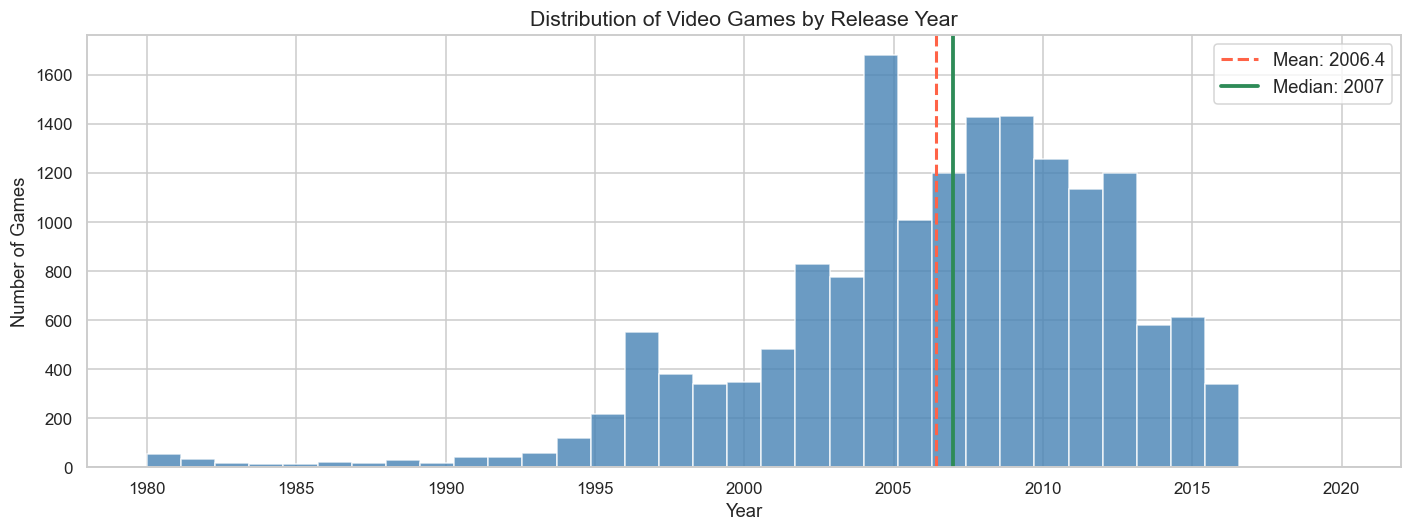

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))

games['Year'].astype(int).hist(bins=35, color='steelblue', alpha=0.8, ax=ax, edgecolor='white')
ax.axvline(year_mean,   color='tomato',   linestyle='--', linewidth=2,   label=f'Mean: {year_mean:.1f}')
ax.axvline(year_median, color='seagreen', linestyle='-',  linewidth=2.5, label=f'Median: {int(year_median)}')

ax.set_title('Distribution of Video Games by Release Year', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Games')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

## 3. Measures of Spread

Spread (variability) describes **how far values deviate from the center**.

| Measure | Formula | Notes |
|---------|---------|-------|
| **Range** | $\max - \min$ | Simple but sensitive to outliers |
| **Variance** | $s^2 = \dfrac{\sum(x_i - \bar{x})^2}{n - 1}$ | Squared deviations; use $n-1$ for samples |
| **Std Dev** | $s = \sqrt{s^2}$ | Same units as the data |
| **IQR** | $Q_3 - Q_1$ | Interquartile range; robust to outliers |

**Bessel's correction** (`ddof=1`): dividing by $n-1$ instead of $n$ gives an **unbiased** estimate  
of the population variance when working with a sample.

**Quartiles:**
- $Q_1$ = 25th percentile (lower quartile)
- $Q_2$ = 50th percentile = median
- $Q_3$ = 75th percentile (upper quartile)
- $IQR = Q_3 - Q_1$ covers the middle 50% of the data

In [6]:
# Exercise: sample std dev of integers 0..99
values = list(range(100))

std_sample = np.std(values, ddof=1)          # sample std (Bessel-corrected)
q1, q3     = np.percentile(values, [25, 75])
iqr        = q3 - q1

print(f"Values: 0 to 99  (n=100)")
print(f"Sample std dev (ddof=1) : {std_sample:.3f}")
print(f"Q1: {q1},  Q3: {q3},  IQR: {iqr}")

Values: 0 to 99  (n=100)
Sample std dev (ddof=1) : 29.011
Q1: 24.75,  Q3: 74.25,  IQR: 49.5


In [7]:
# Nintendo regional sales: mean, median, std across NA / EU / JP / Other
nintendo = games.query('Publisher == "Nintendo"')

regional_stats = nintendo[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].agg(['mean', 'median', 'std'])
print(regional_stats.round(3))
print("\n→ NA_Sales has the highest median — North America is Nintendo's largest market.")

        NA_Sales  EU_Sales  JP_Sales  Other_Sales
mean       1.172     0.601     0.654        0.137
median     0.375     0.120     0.280        0.030
std        2.990     1.744     1.063        0.464

→ NA_Sales has the highest median — North America is Nintendo's largest market.


## 4. Distribution Analysis

Visualizing distributions reveals **shape, skewness, and concentration** of data.

| Plot type | Best for |
|-----------|----------|
| **Histogram** | Continuous variable — shows bins and frequency |
| **Bar chart** | Discrete / categorical variable — shows counts or proportions |
| **KDE** | Smooth density estimate over a continuous variable |

Common shapes: *symmetric (normal)*, *right-skewed* (long tail right), *left-skewed* (long tail left), *bimodal*.

/var/folders/xf/ygl5_zk57kn1rh2h1xj9fyx40000gn/T/ipykernel_94834/941877878.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)


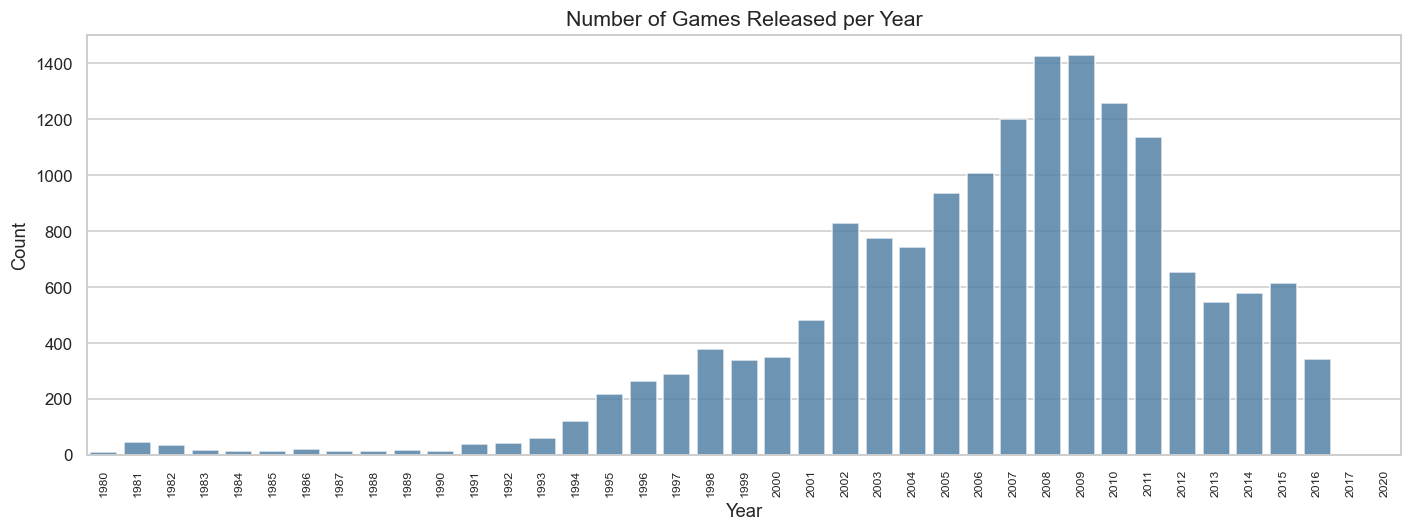

In [8]:
# Releases per year
games_by_year = games.groupby('Year').size().reset_index(name='Count')

fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(x='Year', y='Count', data=games_by_year, color='steelblue', alpha=0.85, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
ax.set_title('Number of Games Released per Year', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

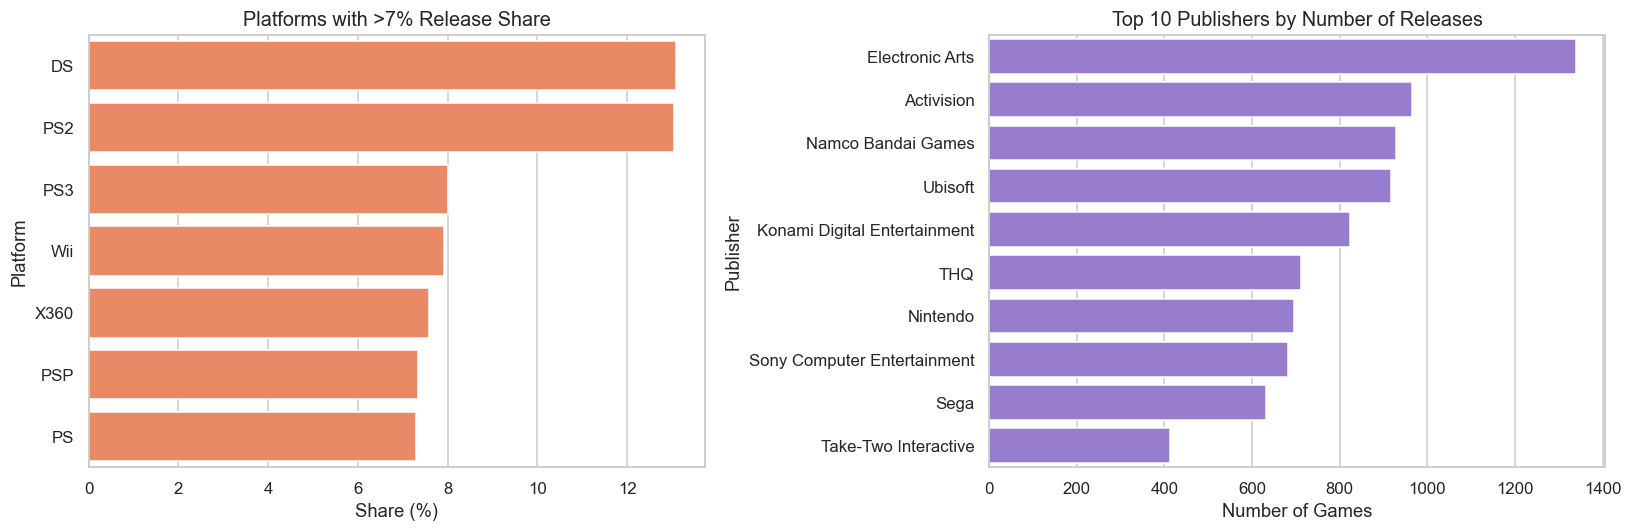

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Platforms with >7% share of all releases
platform_share = games['Platform'].value_counts(normalize=True)
top_platforms  = platform_share[platform_share > 0.07]
sns.barplot(y=top_platforms.index, x=top_platforms.values * 100, color='coral', ax=axes[0])
axes[0].set_title('Platforms with >7% Release Share', fontsize=13)
axes[0].set_xlabel('Share (%)')

# Top 10 publishers by number of titles
top_publishers = games['Publisher'].value_counts().head(10)
sns.barplot(y=top_publishers.index, x=top_publishers.values, color='mediumpurple', ax=axes[1])
axes[1].set_title('Top 10 Publishers by Number of Releases', fontsize=13)
axes[1].set_xlabel('Number of Games')

plt.tight_layout()
plt.show()

## 5. Comparing Groups with Box Plots

A **box plot** summarizes a distribution using 5 numbers:

```
  |----[========|========]----|
 min   Q1     median    Q3   max
```

- The **box** spans $Q_1$ to $Q_3$ (width = IQR)
- The **line** inside the box is the median $Q_2$
- **Whiskers** extend to $1.5 \times IQR$ beyond $Q_1$ / $Q_3$
- Points beyond the whiskers are flagged as **potential outliers**

A **letter-value (boxen) plot** (`sns.boxenplot`) shows additional quantile levels —  
better for large datasets where the tails carry meaningful information.

/var/folders/xf/ygl5_zk57kn1rh2h1xj9fyx40000gn/T/ipykernel_94834/1131956247.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='Genre', y='JP_Sales', data=nintendo, palette='Set2', ax=ax)
/var/folders/xf/ygl5_zk57kn1rh2h1xj9fyx40000gn/T/ipykernel_94834/1131956247.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')


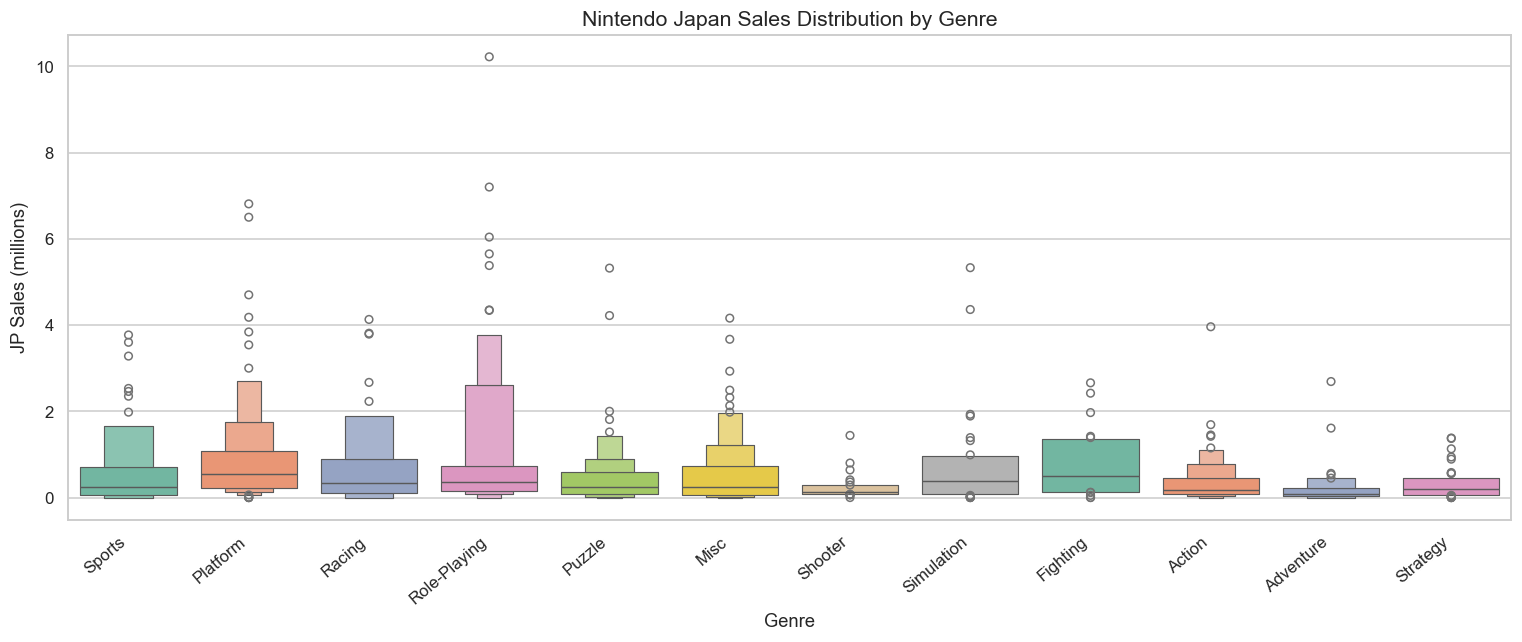

In [10]:
# Nintendo Japan sales by genre
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxenplot(x='Genre', y='JP_Sales', data=nintendo, palette='Set2', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
ax.set_title('Nintendo Japan Sales Distribution by Genre', fontsize=14)
ax.set_xlabel('Genre')
ax.set_ylabel('JP Sales (millions)')
plt.tight_layout()
plt.show()

In [11]:
# IQR per genre — which genres have the most spread in Japan sales?
iqr_by_genre = (
    nintendo
    .groupby('Genre')['JP_Sales']
    .apply(lambda x: x.quantile(0.75) - x.quantile(0.25))
    .sort_values(ascending=False)
    .rename('IQR (JP_Sales)')
)
print(iqr_by_genre.round(3))

Genre
Fighting        1.232
Simulation      0.895
Platform        0.855
Racing          0.790
Misc            0.680
Sports          0.655
Role-Playing    0.580
Puzzle          0.523
Strategy        0.385
Action          0.380
Shooter         0.205
Adventure       0.200
Name: IQR (JP_Sales), dtype: float64


## 6. Trends Over Time

**Line plots** are the standard tool for showing how a quantity changes along an ordered axis.

Steps:
1. Filter to the games of interest
2. Aggregate `Global_Sales` by `(Year, Genre)` using `groupby + sum`
3. Plot with `hue='Genre'` to show one line per genre

We compare 5 Nintendo genres: *Fighting, Simulation, Platform, Racing, Sports*.

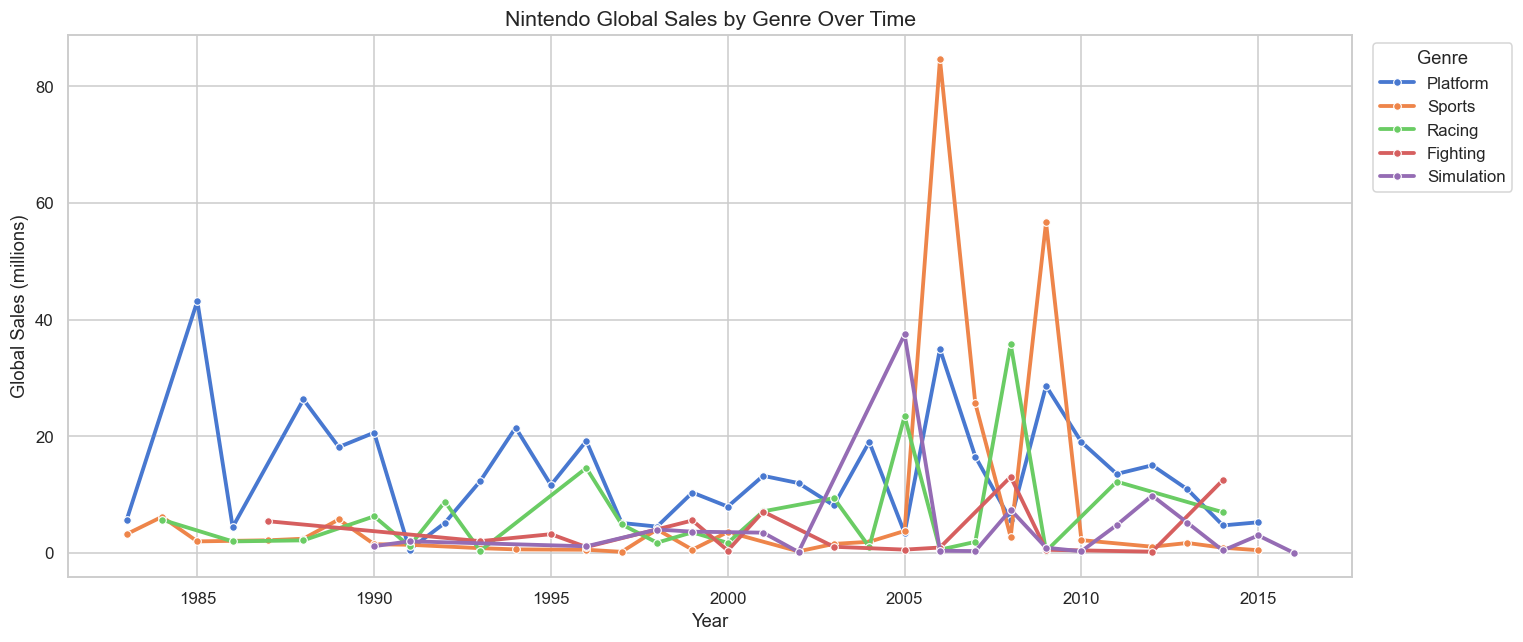

Sports peaked ~2006–2010, driven by Wii Sports and Wii Sports Resort.
Platform games show consistent performance across Nintendo's entire history.


In [12]:
genres_of_interest = ["Fighting", "Simulation", "Platform", "Racing", "Sports"]

nintendo_by_year = (
    nintendo
    .query('Genre in @genres_of_interest')
    .groupby(['Year', 'Genre'], as_index=False)
    .agg({'Global_Sales': 'sum'})
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(x='Year', y='Global_Sales', hue='Genre', data=nintendo_by_year,
             linewidth=2.5, marker='o', markersize=5, ax=ax)
ax.set_title('Nintendo Global Sales by Genre Over Time', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Global Sales (millions)')
ax.legend(title='Genre', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Sports peaked ~2006–2010, driven by Wii Sports and Wii Sports Resort.")
print("Platform games show consistent performance across Nintendo's entire history.")